# TP3 — Conclusiones Generales

**Alumno:** Gonzalo Zarazaga

---

Cierre del TP: consolida en un solo lugar las conclusiones repartidas en `02_modelos_clasicos.ipynb`, `04_clasificacion_w2v.ipynb` y `05_topicos_temporales.ipynb` — comparación final de los cuatro modelos de clasificación y hallazgos del análisis de tópicos.

## 1. Comparación final de los cuatro modelos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

tabla_final = pd.read_csv("../data/processed/comparacion_enfoques_final.csv", index_col=0)
tabla_final

,accuracy_val,f1_val,auc_val,accuracy_manual,f1_manual,auc_manual,accuracy_manual_ci_low,accuracy_manual_ci_high
TextBlob (baseline),0.6115,0.6989,0.6879,0.6880,0.7522,0.7974,0.640,0.736
BoW + Naive Bayes,0.7739,0.7733,0.8479,0.8106,0.8152,0.8882,0.770,0.851
TF-IDF + Logistic Regression,0.7866,0.7902,0.8667,0.7967,0.8053,0.8912,0.755,0.838
Word2Vec + Logistic Regression,0.7706,0.7705,0.8505,0.8162,0.8187,0.8723,0.776,0.856


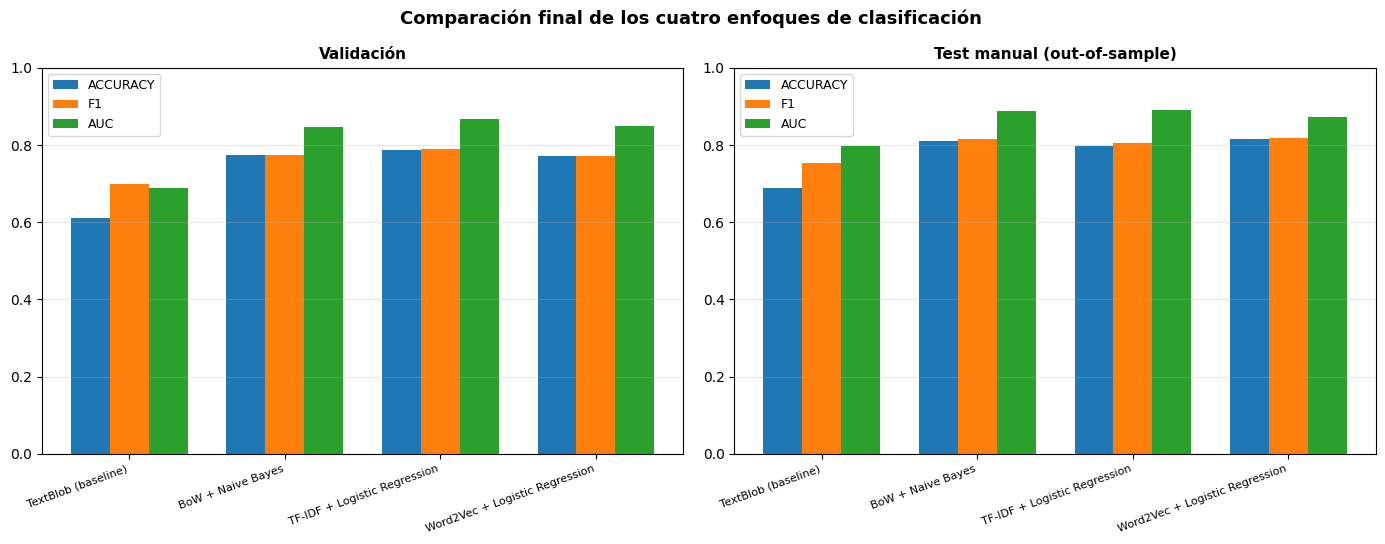

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colores = ["#95a5a6", "#3498db", "#e74c3c", "#8e44ad"]

for ax, sufijo, titulo in zip(axes, ["_val", "_manual"], ["Validación", "Test manual (out-of-sample)"]):
    metricas = ["accuracy", "f1", "auc"]
    x = np.arange(len(tabla_final.index))
    width = 0.25
    for i, metrica in enumerate(metricas):
        ax.bar(x + i * width, tabla_final[f"{metrica}{sufijo}"], width, label=metrica.upper())
    ax.set_xticks(x + width)
    ax.set_xticklabels(tabla_final.index, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Comparación final de los cuatro enfoques de clasificación", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusiones sobre los modelos

- **TextBlob (baseline pre-entrenado)** queda consistentemente último en las tres métricas y en ambos conjuntos (accuracy 0,61 en validación, 0,69 en manual) — cumple su rol de cota inferior: cualquier modelo entrenado sobre el corpus debía superarlo, y los tres lo hacen con margen. Esta diferencia es estadísticamente sólida incluso en el test manual: su intervalo de confianza (95%, n=359) es [0,64–0,74], y no se solapa con el de ningún modelo entrenado.
- **BoW + Naive Bayes** y **TF-IDF + Logistic Regression** son los más fuertes en validación (accuracy 0,77 y 0,79 respectivamente), con TF-IDF+LR liderando las tres métricas ahí.
- **Sobre el ranking en el test manual, con la cautela estadística que corresponde**: Word2Vec + LR tiene el accuracy puntual más alto ahí (0,816 vs. 0,797 de TF-IDF+LR), pero con n=359 el margen de error de cada estimación ronda ±4 puntos porcentuales y los intervalos de confianza de los tres modelos entrenados se solapan casi por completo ([0,77–0,85], [0,76–0,84], [0,78–0,86]). No se puede afirmar con esta muestra cuál de los tres generaliza mejor — la diferencia observada puede ser ruido de muestreo.
- **Lo que sí se sostiene**: ningún modelo entrenado se derrumba en el test manual — los tres mantienen o mejoran sus métricas al pasar de validación (etiquetado automático por emoticon) al test manual (etiquetado con una metodología distinta, ver nota de la fuente en `00_lectura_y_discovery.ipynb`) — evidencia de que no memorizaron el heurístico de etiquetado, sino que aprendieron señal de sentimiento que generaliza.
- **No hay un único "mejor modelo" sin ambigüedad**: en validación gana TF-IDF+LR con margen razonable; en el test manual los tres modelos entrenados quedan estadísticamente empatados entre sí, y todos superan claramente a TextBlob.

## 2. Conclusiones sobre los tópicos (diferenciador)

De `05_topicos_temporales.ipynb`, entrenando BERTopic sobre una muestra de 80.000 tweets:

- **Los tópicos dominantes por volumen son charla cotidiana** (sueño/cama, agradecimientos, mascotas, clima, cumpleaños, el propio Twitter), no eventos noticiosos. Irán **no es "el tópico principal"** del dataset — es el caso de éxito elegido entre los eventos candidatos para poner a prueba la metodología de detección de eventos por picos de volumen, no el tópico con más tweets.
- **Confirmado**: el tópico de la elección/protestas en Irán (`iran`, `iranelection`, `tehran`, `iranian`) es prácticamente inexistente antes del 12/6/2009 (3 tweets) y explota el 15/6 (77 tweets totales, la mayoría desde el 15/6 en adelante) — una validación externa clara de que picos de volumen temático detectan eventos reales, no ruido.
- **El sentimiento del tópico es coherente con el evento**: ~86% de los tweets del tópico Irán son negativos, frente al ~50% esperado por el balance del dataset — conecta el hallazgo de tópicos con el resto del análisis de sentimiento del TP.
- **Triangulación independiente** (`00b_eda_contenido.ipynb`): un conteo simple de hashtags (sin ningún modelo) muestra a `#iranelection` entre los más frecuentes del lado negativo del corpus completo (518 menciones) — dos métodos distintos, clustering de embeddings y conteo de hashtags, coinciden en la misma señal.
- **¿Por qué BERTopic y no K-Means/DBSCAN?** (`05b_clustering_manual.ipynb`): se armó el mismo pipeline "a mano" (K-Means y DBSCAN de scikit-learn en vez de HDBSCAN) sobre la misma muestra, embeddings y espacio UMAP. BERTopic/HDBSCAN gana en calidad global de clustering (silhouette 0,558 vs. 0,357 de K-Means y 0,095 del mejor DBSCAN) — pero **no** porque sea el único capaz de encontrar el tópico de Irán: un DBSCAN bien afinado también lo aísla, con tamaño casi idéntico (77 tweets). La ventaja real de HDBSCAN es la calidad del resto de la partición, sin depender de un único radio de densidad global como DBSCAN. K-Means, en cambio, sí falla en aislar Irán — con K fijo y sin noción de ruido, lo mezcla dentro de un cluster genérico de "meta-Twitter" (tweetdeck, followers, hacked).
- **Hipótesis corregida, no forzada**: se había planteado que el límite superior de fechas del dataset (25/6/2009) coincidiría con la muerte de Michael Jackson. Los datos muestran que la recolección corta a las 10:28 (PDT) de ese día, ~4 horas antes del anuncio (~14:26 PDT) — no llegó a formar un tópico propio, y se documentó esa corrección en vez de sostener una conclusión no respaldada por los datos.

## 3. Métrica obligatoria: similitud coseno, tres contextos

1. **Nivel palabra** (`03_word2vec.ipynb`): similitud entre pares de sentimiento opuesto (`happy`/`sad`, `good`/`bad`, `love`/`hate`) y vecinos más cercanos en el espacio Word2Vec.
2. **Nivel documento** (`04_clasificacion_w2v.ipynb`): comparación de tweets completos (promedio de embeddings) vía distancia coseno — tweets de la misma polaridad quedan más cerca entre sí que tweets de polaridad opuesta.
3. **Modelado de tópicos** (`05_topicos_temporales.ipynb`): BERTopic usa cosine similarity internamente en `c-TF-IDF` y en la reducción `UMAP` (`metric="cosine"` explícito).

## 4. Cierre

El TP cubre los tres enfoques de clasificación de sentimiento pedidos (baseline pre-entrenado, modelos clásicos con representaciones dispersas, Word2Vec propio) más un diferenciador de detección de eventos reales vía tópicos temporales — con la decisión sobre el dataset de test manual, la disciplina fit/transform, y las correcciones de hipótesis documentadas a lo largo del proceso, no solo el resultado final.